In [64]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [65]:
df = pd.read_csv('/content/drive/MyDrive/Daksh_Gururkul_IITG_May_2025/11_Projects/zomato.csv', encoding='utf-8')
df.sample(5)

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
43045,https://www.zomato.com/bangalore/bhaiyaji-food...,"14, B Wing Mittal Tower, MG Road, Bangalore",Bhaiyaji Food Court,No,No,3.4 /5,27,080 25328999\n+91 9535906582,MG Road,Quick Bites,"Paratha, Samosa, Vada Pav","North Indian, Mithai",300,"[('Rated 3.0', 'RATED\n Been there on several...",[],Desserts,MG Road
17386,https://www.zomato.com/bangalore/wimpie-cafe-r...,"OYO Flagship, 12476 IRA Residency, 9/13 HSR, O...",Wimpie Cafe & Restaurant,Yes,No,NEW,0,+91 9591014229,Bellandur,Casual Dining,NaN,"North Indian, Mughlai, Biryani",600,"[('Rated 5.0', ""RATED\n Last Night we had bes...",[],Dine-out,HSR
51250,https://www.zomato.com/bangalore/the-waverly-e...,"UG Floor, VR Mall, Whitefield, Bangalore",The Waverly Express,No,No,3.5 /5,12,+91 9108481279,Whitefield,Cafe,NaN,Cafe,650,"[('Rated 4.0', 'RATED\n Was part of the desse...",[],Dine-out,Whitefield
1408,https://www.zomato.com/bangalore/bbq-ride-46-b...,"7th Cross, Near ICICI Bank, 15th Main, 2nd Sta...",BBQ Ride 46,Yes,No,3.4/5,7,+91 8886780880,South Bangalore,Food Truck,NaN,BBQ,200,"[('Rated 4.0', 'RATED\n This was my first tim...",[],Delivery,Bannerghatta Road
37199,https://www.zomato.com/bangalore/indian-chicke...,"117, Neelasandra Bazar Street, Rose Garden Bus...",Indian Chicken Biryani Point,Yes,No,3.3 /5,9,+91 9845866723\n+91 8892868707,Richmond Road,Quick Bites,NaN,"Biryani, South Indian",300,"[('Rated 1.0', 'RATED\n food is very poor'), ...","['Chicken Biryani', 'Chicken Fried Rice', 'Chi...",Dine-out,Koramangala 7th Block


In [66]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51717 entries, 0 to 51716
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   url                          51717 non-null  object
 1   address                      51717 non-null  object
 2   name                         51717 non-null  object
 3   online_order                 51717 non-null  object
 4   book_table                   51717 non-null  object
 5   rate                         43942 non-null  object
 6   votes                        51717 non-null  int64 
 7   phone                        50509 non-null  object
 8   location                     51696 non-null  object
 9   rest_type                    51490 non-null  object
 10  dish_liked                   23639 non-null  object
 11  cuisines                     51672 non-null  object
 12  approx_cost(for two people)  51371 non-null  object
 13  reviews_list                 51

In [67]:
#df['menu_item'].value_counts()

In [68]:
df.columns

Index(['url', 'address', 'name', 'online_order', 'book_table', 'rate', 'votes',
       'phone', 'location', 'rest_type', 'dish_liked', 'cuisines',
       'approx_cost(for two people)', 'reviews_list', 'menu_item',
       'listed_in(type)', 'listed_in(city)'],
      dtype='object')

In [69]:
df = df.drop(['address','phone', 'dish_liked','listed_in(city)','cuisines','reviews_list', 'menu_item'],axis=1)
df.head()

,url,name,online_order,book_table,rate,votes,location,rest_type,approx_cost(for two people),listed_in(type)
0,https://www.zomato.com/bangalore/jalsa-banasha...,Jalsa,Yes,Yes,4.1/5,775,Banashankari,Casual Dining,800,Buffet
1,https://www.zomato.com/bangalore/spice-elephan...,Spice Elephant,Yes,No,4.1/5,787,Banashankari,Casual Dining,800,Buffet
2,https://www.zomato.com/SanchurroBangalore?cont...,San Churro Cafe,Yes,No,3.8/5,918,Banashankari,"Cafe, Casual Dining",800,Buffet
3,https://www.zomato.com/bangalore/addhuri-udupi...,Addhuri Udupi Bhojana,No,No,3.7/5,88,Banashankari,Quick Bites,300,Buffet
4,https://www.zomato.com/bangalore/grand-village...,Grand Village,No,No,3.8/5,166,Basavanagudi,Casual Dining,600,Buffet


In [70]:
df['rate'].unique()

array(['4.1/5', '3.8/5', '3.7/5', '3.6/5', '4.6/5', '4.0/5', '4.2/5',
       '3.9/5', '3.1/5', '3.0/5', '3.2/5', '3.3/5', '2.8/5', '4.4/5',
       '4.3/5', 'NEW', '2.9/5', '3.5/5', nan, '2.6/5', '3.8 /5', '3.4/5',
       '4.5/5', '2.5/5', '2.7/5', '4.7/5', '2.4/5', '2.2/5', '2.3/5',
       '3.4 /5', '-', '3.6 /5', '4.8/5', '3.9 /5', '4.2 /5', '4.0 /5',
       '4.1 /5', '3.7 /5', '3.1 /5', '2.9 /5', '3.3 /5', '2.8 /5',
       '3.5 /5', '2.7 /5', '2.5 /5', '3.2 /5', '2.6 /5', '4.5 /5',
       '4.3 /5', '4.4 /5', '4.9/5', '2.1/5', '2.0/5', '1.8/5', '4.6 /5',
       '4.9 /5', '3.0 /5', '4.8 /5', '2.3 /5', '4.7 /5', '2.4 /5',
       '2.1 /5', '2.2 /5', '2.0 /5', '1.8 /5'], dtype=object)

In [71]:
float('4.1/5'.split('/')[0])

4.1

In [72]:
def cleaning_rate(value):
  if (value == 'NEW' or value == '-'):
    return np.nan
  else:
    return float(str(value).split('/')[0])

In [73]:
df['rate'] = df['rate'].apply(cleaning_rate)
df['rate'].unique()

array([4.1, 3.8, 3.7, 3.6, 4.6, 4. , 4.2, 3.9, 3.1, 3. , 3.2, 3.3, 2.8,
       4.4, 4.3, nan, 2.9, 3.5, 2.6, 3.4, 4.5, 2.5, 2.7, 4.7, 2.4, 2.2,
       2.3, 4.8, 4.9, 2.1, 2. , 1.8])

In [74]:
df.isna().sum()

,0
url,0
name,0
online_order,0
book_table,0
rate,10052
votes,0
location,21
rest_type,227
approx_cost(for two people),346
listed_in(type),0


In [75]:
df['rate'] = df['rate'].fillna(np.round(df['rate'].mean(),1))

In [76]:
df.isna().sum()

,0
url,0
name,0
online_order,0
book_table,0
rate,0
votes,0
location,21
rest_type,227
approx_cost(for two people),346
listed_in(type),0


In [77]:
df = df.dropna()


In [78]:
df.duplicated().sum()

np.int64(0)

In [79]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 51167 entries, 0 to 51716
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   url                          51167 non-null  object 
 1   name                         51167 non-null  object 
 2   online_order                 51167 non-null  object 
 3   book_table                   51167 non-null  object 
 4   rate                         51167 non-null  float64
 5   votes                        51167 non-null  int64  
 6   location                     51167 non-null  object 
 7   rest_type                    51167 non-null  object 
 8   approx_cost(for two people)  51167 non-null  object 
 9   listed_in(type)              51167 non-null  object 
dtypes: float64(1), int64(1), object(8)
memory usage: 4.3+ MB


In [80]:
df['approx_cost(for two people)'].unique()

array(['800', '300', '600', '700', '550', '500', '450', '650', '400',
       '900', '200', '750', '150', '850', '100', '1,200', '350', '250',
       '950', '1,000', '1,500', '1,300', '199', '80', '1,100', '160',
       '1,600', '230', '130', '50', '190', '1,700', '1,400', '180',
       '1,350', '2,200', '2,000', '1,800', '1,900', '330', '2,500',
       '2,100', '3,000', '2,800', '3,400', '40', '1,250', '3,500',
       '4,000', '2,400', '2,600', '120', '1,450', '469', '70', '3,200',
       '60', '560', '240', '360', '6,000', '1,050', '2,300', '4,100',
       '5,000', '3,700', '1,650', '2,700', '4,500', '140'], dtype=object)

In [81]:
def cleaned_cost(value):
  if ',' in value:
    value = value.replace(',','')
    return float(value)
  else:
    return float(value)

In [82]:
df['approx_cost(for two people)'] = df['approx_cost(for two people)'].apply(cleaned_cost)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 51167 entries, 0 to 51716
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   url                          51167 non-null  object 
 1   name                         51167 non-null  object 
 2   online_order                 51167 non-null  object 
 3   book_table                   51167 non-null  object 
 4   rate                         51167 non-null  float64
 5   votes                        51167 non-null  int64  
 6   location                     51167 non-null  object 
 7   rest_type                    51167 non-null  object 
 8   approx_cost(for two people)  51167 non-null  float64
 9   listed_in(type)              51167 non-null  object 
dtypes: float64(2), int64(1), object(7)
memory usage: 4.3+ MB


In [83]:
df['approx_cost(for two people)'].unique()

array([ 800.,  300.,  600.,  700.,  550.,  500.,  450.,  650.,  400.,
        900.,  200.,  750.,  150.,  850.,  100., 1200.,  350.,  250.,
        950., 1000., 1500., 1300.,  199.,   80., 1100.,  160., 1600.,
        230.,  130.,   50.,  190., 1700., 1400.,  180., 1350., 2200.,
       2000., 1800., 1900.,  330., 2500., 2100., 3000., 2800., 3400.,
         40., 1250., 3500., 4000., 2400., 2600.,  120., 1450.,  469.,
         70., 3200.,   60.,  560.,  240.,  360., 6000., 1050., 2300.,
       4100., 5000., 3700., 1650., 2700., 4500.,  140.])

In [84]:
restaurant_type = df['rest_type'].value_counts()

In [85]:
type_below_500 = restaurant_type[restaurant_type < 500]

In [86]:
def cleaned_type(value):
  if (value in type_below_500):
    return 'Others'
  else:
    return value

In [87]:
df['rest_type'] = df['rest_type'].apply(cleaned_type)
df['rest_type'].value_counts()#.plot(kind='bar')

,count
rest_type,
Quick Bites,19048
Casual Dining,10275
Others,6860
Cafe,3687
Delivery,2587
Dessert Parlor,2245
"Takeaway, Delivery",2016
Bakery,1141
"Casual Dining, Bar",1136


In [88]:
res_loc = df['location'].value_counts()
loc_below_200 = res_loc[res_loc < 200]


In [89]:
def cleaning_location(loc):
  if loc in loc_below_200:
    return 'Others'
  elif ('Koramangala' in loc):
    return 'Koramangala'
  else:
    return loc

In [90]:
df['location']= df['location'].apply(cleaning_location)
df['location'].value_counts()

,count
location,
Koramangala,7550
BTM,5071
Others,3412
HSR,2496
JP Nagar,2219
Whitefield,2117
Indiranagar,2033
Jayanagar,1916
Marathahalli,1811


# Restaurants delivering Online or not

Text(0.5, 1.0, 'Restaurants delivering online or not')

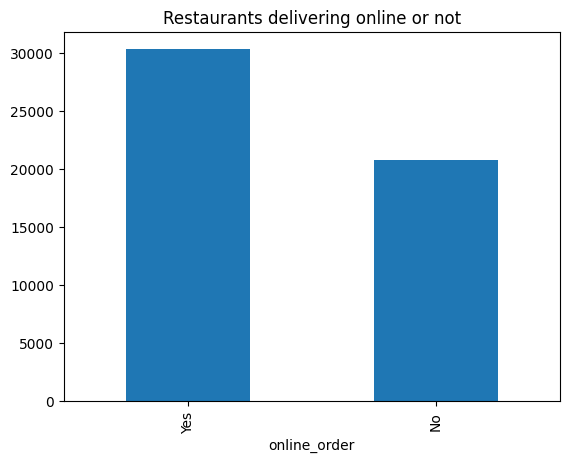

In [95]:
df['online_order'].value_counts().plot(kind='bar')
plt.title('Restaurants delivering online or not')

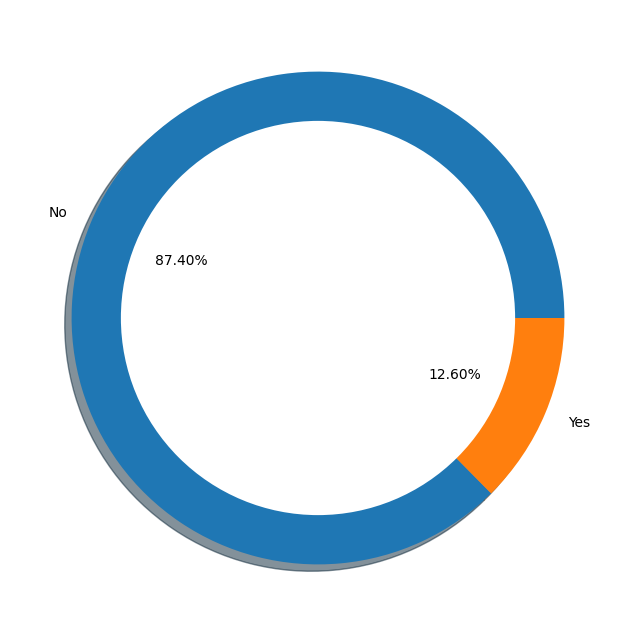

In [119]:
plt.figure(figsize=(8,8))
plt.pie(df['book_table'].value_counts().values, labels=df['book_table'].value_counts().index,
        autopct='%1.2f%%', shadow=True)
centre_circle = plt.Circle((0,0), 0.8, fc='white')

fig = plt.gcf() #Gets current figure
fig.gca().add_artist(centre_circle) #Adds white circle to the center
plt.show()

In [109]:
df['book_table'].value_counts()#.index

,count
book_table,
No,44718
Yes,6449


In [110]:
6449/(6449+44718)

0.12603826685168174

<Axes: xlabel='location'>

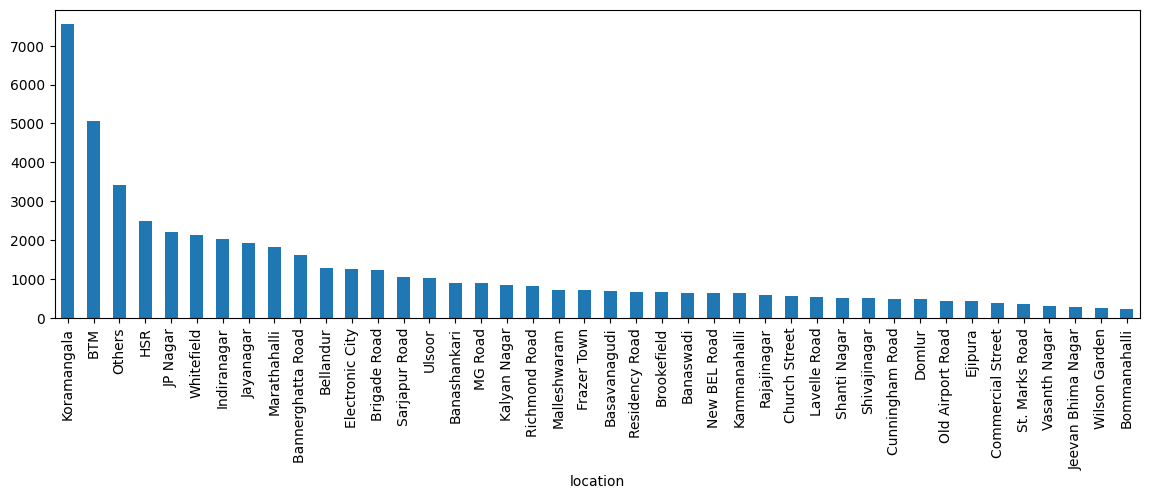

In [124]:
plt.figure(figsize=(14,4))
df['location'].value_counts().plot(kind='bar')

<Axes: ylabel='rest_type'>

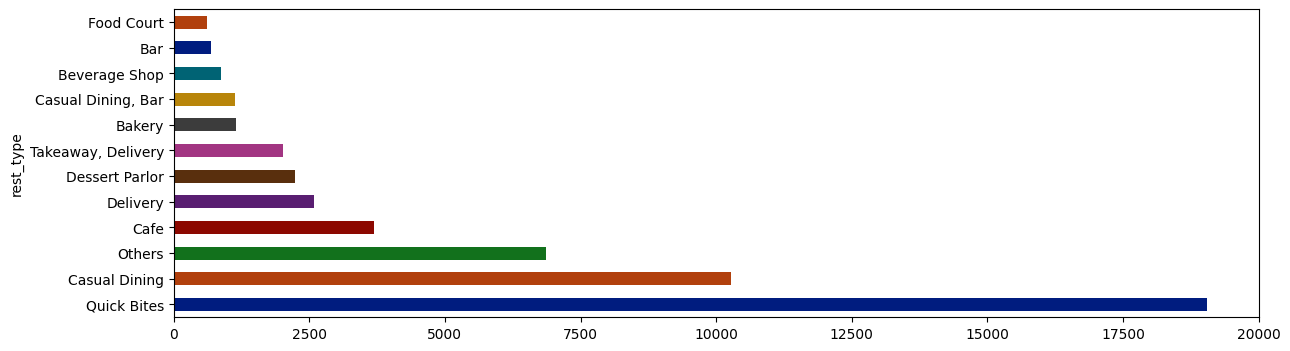

In [127]:
plt.figure(figsize=(14,4))
df['rest_type'].value_counts().plot(kind='barh', color=sns.color_palette('dark'))

In [148]:
df['approx_cost(for two people)'].groupby(df['name'],sort=True)

Text(0.5, 1.0, 'Avg cost for 2 people - Top 10 restaurants')

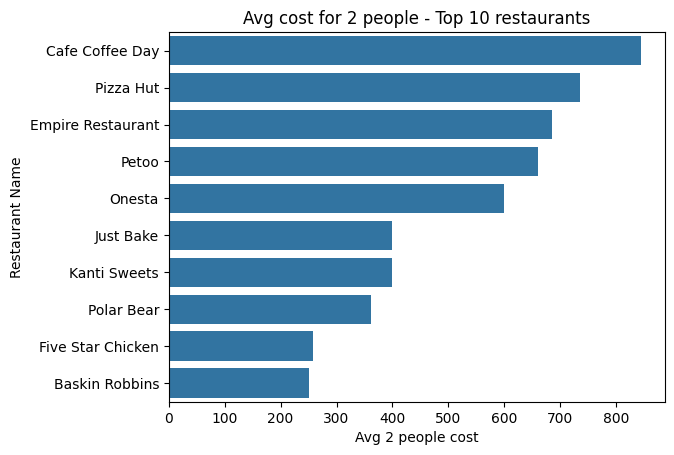

In [146]:
res_cost = df['approx_cost(for two people)'].groupby(df['name'],sort=True)


dict1 = {}


for i,j in df['name'].value_counts()[:10].to_dict().items():
  dict1[i] = np.round(res_cost.get_group(i).mean(), 2)


cost_df = pd.DataFrame(list(dict1.items()), columns = ['Restaurant Name', 'Avg 2 people cost'])

sns.barplot(data=cost_df.sort_values(by=['Avg 2 people cost'], ascending=False),
            x = 'Avg 2 people cost',y='Restaurant Name')
plt.title('Avg cost for 2 people - Top 10 restaurants')

Text(0.5, 1.0, 'Avg Ratings - Top 10 restaurants')

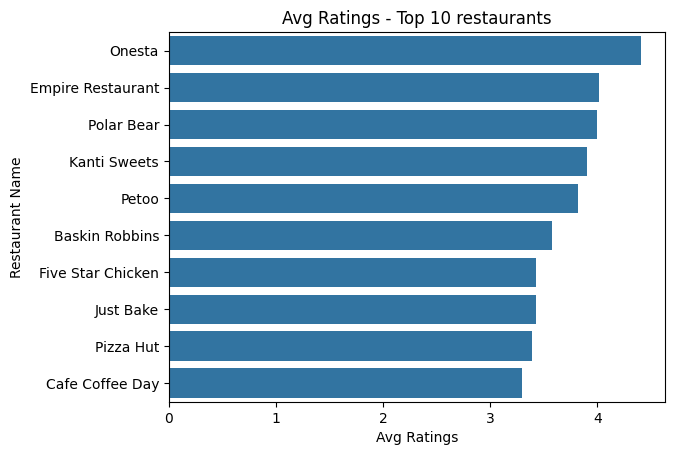

In [147]:
res_chain = df['rate'].groupby(df['name'],sort=True)

dict2 = {}

for i,j in df['name'].value_counts()[:10].to_dict().items():
  dict2[i] = np.round(res_chain.get_group(i).mean(), 2)

cost_df2 = pd.DataFrame(list(dict2.items()), columns = ['Restaurant Name', 'Avg Ratings'])

sns.barplot(data=cost_df2.sort_values(by=['Avg Ratings'], ascending=False),
            x = 'Avg Ratings',y='Restaurant Name')
plt.title('Avg Ratings - Top 10 restaurants')

In [149]:
dict2

{'Cafe Coffee Day': np.float64(3.3),
 'Onesta': np.float64(4.41),
 'Just Bake': np.float64(3.43),
 'Empire Restaurant': np.float64(4.02),
 'Five Star Chicken': np.float64(3.43),
 'Kanti Sweets': np.float64(3.9),
 'Petoo': np.float64(3.82),
 'Polar Bear': np.float64(4.0),
 'Baskin Robbins': np.float64(3.58),
 'Pizza Hut': np.float64(3.39)}

In [150]:
dict1

{'Cafe Coffee Day': np.float64(844.79),
 'Onesta': np.float64(600.0),
 'Just Bake': np.float64(400.0),
 'Empire Restaurant': np.float64(685.21),
 'Five Star Chicken': np.float64(257.86),
 'Kanti Sweets': np.float64(400.0),
 'Petoo': np.float64(659.85),
 'Polar Bear': np.float64(361.54),
 'Baskin Robbins': np.float64(251.56),
 'Pizza Hut': np.float64(736.29)}